<a href="https://colab.research.google.com/github/john-dechellis-weather/wx_compare/blob/main/AircraftSatellite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install goes2go

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 107.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviou

In [ ]:
import goes2go
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

print("goes2go imported successfully")

 ╭─goes2go──────────────────────────────────────────────╮
 │ INFO: Created a default config file.                 │
 │ You may view/edit goes2go's configuration here:      │
 │           /root/.config/goes2go/config.toml          │
 ╰──────────────────────────────────────────────────────╯

goes2go imported successfully


In [ ]:
import sys, numpy, pandas, requests, PIL, matplotlib
print("python   ", sys.version)
print("numpy    ", numpy.__version__)
print("pandas   ", pandas.__version__)
print("requests ", requests.__version__)
print("pillow   ", PIL.__version__)
print("mpl      ", matplotlib.__version__)

python    3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
numpy     2.0.2
pandas    3.0.3
requests  2.32.4
pillow    11.3.0
mpl       3.10.0


In [ ]:
from datetime import datetime
from goes2go.data import goes_nearesttime

target_time = datetime(2026, 7, 6, 23, 59)

ds = goes_nearesttime(
    attime=target_time,
    satellite="goes19",     # GOES-East
    product="ABI-L2-MCMIP",
    domain="F",             # Full Disk is safest; can try "C" later
    return_as="xarray",
    download=True,
    overwrite=False,
    verbose=True,
)

print(ds)
print(ds.attrs.get("dataset_name", "no dataset_name attr"))
print(ds["nominal_satellite_subpoint_lon"].values)

📦 Finished downloading [1] files to [/root/data/noaa-goes19/ABI-L2-MCMIPF].
📚 Finished reading [1] files into xarray.Dataset.
<xarray.Dataset> Size: 4GB
Dimensions:                                 (y: 5424, x: 5424,
                                             number_of_time_bounds: 2,
                                             number_of_image_bounds: 2, band: 1)
Coordinates: (12/41)
  * y                                       (y) float32 22kB 0.1518 ... -0.1518
  * x                                       (x) float32 22kB -0.1518 ... 0.1518
    t                                       datetime64[ns] 8B 2026-07-07T00:0...
    y_image                                 float32 4B 0.0
    x_image                                 float32 4B 0.0
    band_wavelength_C01                     (band) float32 4B 0.47
    ...                                      ...
    band_id_C15                             (band) int8 1B 15
    band_id_C16                             (band) int8 1B 16
    dataset_

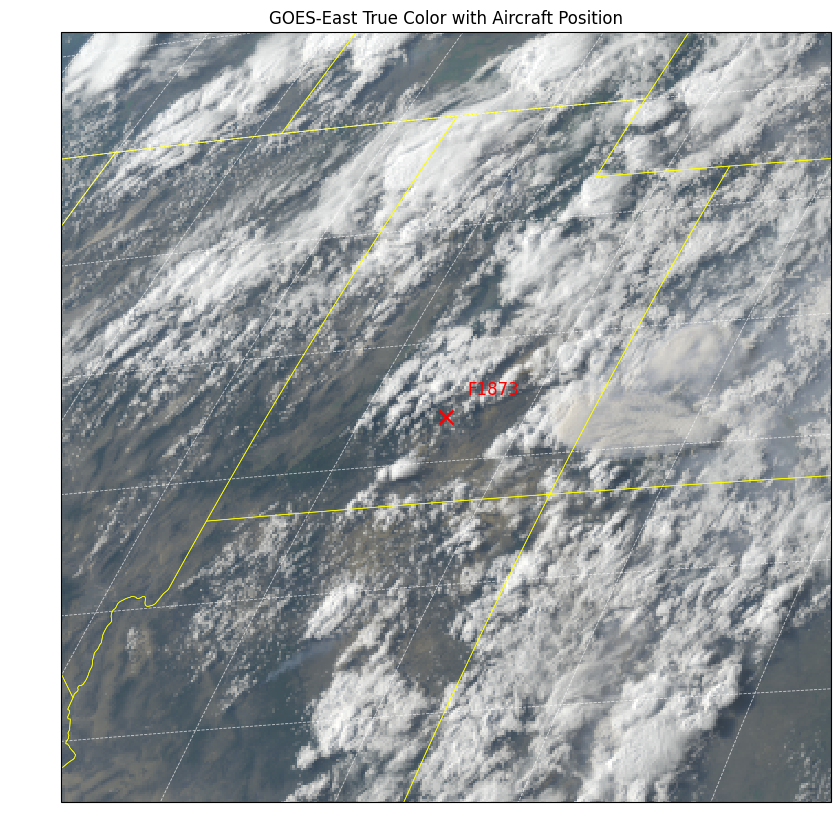

In [ ]:
import matplotlib.pyplot as plt
import pyproj
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# USER INPUTS
# -----------------------------
aircraft_lat = 38.0494
aircraft_lon = -111.2056

# -----------------------------
# EXTRACT TRUE COLOR BANDS
# -----------------------------
R = ds["CMI_C02"].values  # Red
G = ds["CMI_C03"].values  # Veggie band
B = ds["CMI_C01"].values  # Blue

R = np.clip(R, 0, 1)
G = np.clip(G, 0, 1)
B = np.clip(B, 0, 1)

# Approximate true green
G_true = np.clip(0.45 * R + 0.10 * G + 0.45 * B, 0, 1)

# Gamma correction
gamma = 2.2
R = np.power(R, 1 / gamma)
G_true = np.power(G_true, 1 / gamma)
B = np.power(B, 1 / gamma)

RGB = np.dstack([R, G_true, B])

# Optional small contrast/brightness boost
RGB = np.clip((RGB - 0.02) / 0.9, 0, 1)
RGB = np.clip(RGB * 1.15, 0, 1)

# -----------------------------
# GOES PROJECTION INFO
# -----------------------------
proj_var = ds["goes_imager_projection"]
sat_h = float(proj_var.perspective_point_height)
lon_0 = float(proj_var.longitude_of_projection_origin)
sweep = str(proj_var.sweep_angle_axis)

x = ds["x"].values * sat_h
y = ds["y"].values * sat_h

# Cartopy GOES projection
geos_crs = ccrs.Geostationary(
    central_longitude=lon_0,
    satellite_height=sat_h,
    sweep_axis=sweep
)

# PyProj transformer for aircraft point
geos_proj = pyproj.Proj(proj="geos", h=sat_h, lon_0=lon_0, sweep=sweep)
wgs84 = pyproj.Proj(proj="latlong", datum="WGS84")
transformer = pyproj.Transformer.from_proj(wgs84, geos_proj, always_xy=True)
aircraft_x, aircraft_y = transformer.transform(aircraft_lon, aircraft_lat)

# -----------------------------
# PLOT
# -----------------------------
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=geos_crs)

ax.imshow(
    RGB,
    origin="upper",
    extent=[x.min(), x.max(), y.min(), y.max()],
    transform=geos_crs,
    interpolation="nearest"
)

# Geographic overlays
ax.coastlines(resolution="10m", color="white", linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), edgecolor="white", linewidth=0.5)
ax.add_feature(cfeature.STATES.with_scale("10m"), edgecolor="yellow", linewidth=0.5, facecolor="none")

# Lat/lon grid
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.6,
    color="white",
    alpha=0.7,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 9, "color": "white"}
gl.ylabel_style = {"size": 9, "color": "white"}

# Aircraft marker
ax.scatter(
    aircraft_x,
    aircraft_y,
    s=100,
    marker="x",
    color="red",
    zorder=10
)

ax.text(
    aircraft_x + 20000,
    aircraft_y + 20000,
    "F1873",
    color="red",
    fontsize=12,
    zorder=10
)

# Zoom
pad = 350000
ax.set_xlim(aircraft_x - pad, aircraft_x + pad)
ax.set_ylim(aircraft_y - pad, aircraft_y + pad)

plt.title("GOES-East True Color with Aircraft Position")
plt.show()

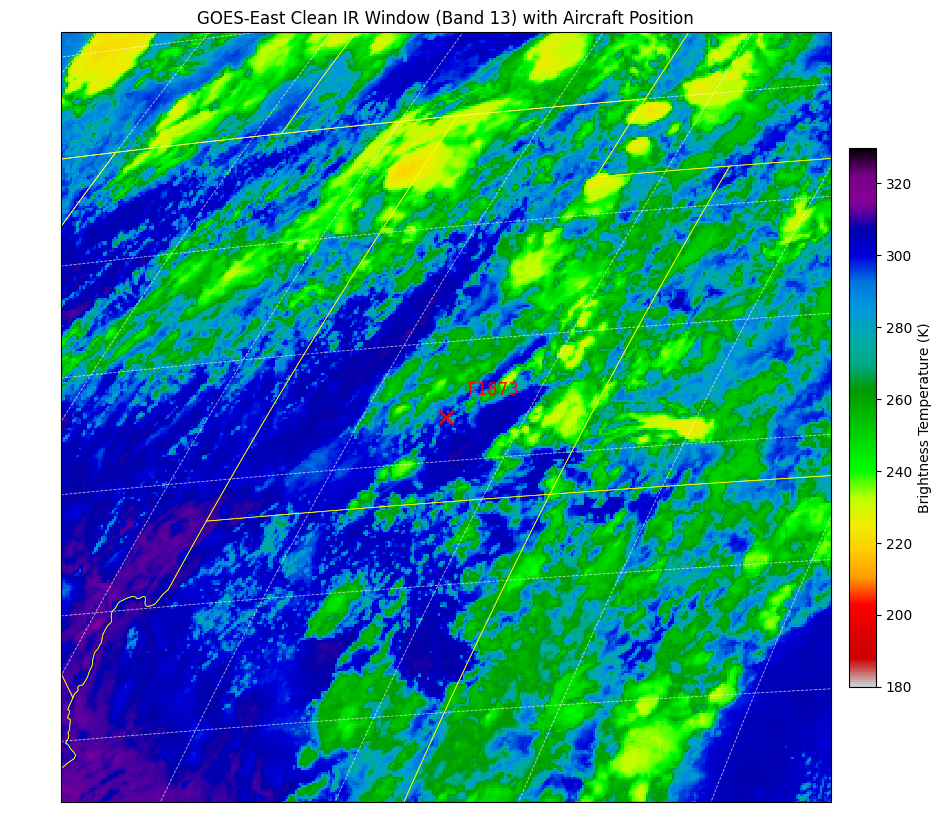

In [ ]:
import matplotlib.pyplot as plt
import pyproj
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# USER INPUTS
# -----------------------------
aircraft_lat = 38.0494
aircraft_lon = -111.2056

# -----------------------------
# EXTRACT IR CLEAN WINDOW BAND
# -----------------------------
# GOES ABI Band 13 = Clean IR Window (~10.3 um)
ir = ds["CMI_C13"].values

# Mask bad values if needed
ir = np.ma.masked_invalid(ir)

# Typical brightness temperature range in Kelvin
# Colder cloud tops = lower temperatures
vmin = 180   # very cold cloud tops
vmax = 330   # warm surface / low clouds

# -----------------------------
# GOES PROJECTION INFO
# -----------------------------
proj_var = ds["goes_imager_projection"]
sat_h = float(proj_var.perspective_point_height)
lon_0 = float(proj_var.longitude_of_projection_origin)
sweep = str(proj_var.sweep_angle_axis)

x = ds["x"].values * sat_h
y = ds["y"].values * sat_h

# Cartopy GOES projection
geos_crs = ccrs.Geostationary(
    central_longitude=lon_0,
    satellite_height=sat_h,
    sweep_axis=sweep
)

# PyProj transformer for aircraft point
geos_proj = pyproj.Proj(proj="geos", h=sat_h, lon_0=lon_0, sweep=sweep)
wgs84 = pyproj.Proj(proj="latlong", datum="WGS84")
transformer = pyproj.Transformer.from_proj(wgs84, geos_proj, always_xy=True)
aircraft_x, aircraft_y = transformer.transform(aircraft_lon, aircraft_lat)

# -----------------------------
# PLOT
# -----------------------------
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=geos_crs)

# For IR imagery, use a grayscale colormap.
# "Greys" gives cold clouds darker; add _r to reverse if preferred.
img = ax.imshow(
    ir,
    origin="upper",
    extent=[x.min(), x.max(), y.min(), y.max()],
    transform=geos_crs,
    cmap="nipy_spectral_r",
    vmin=180,
    vmax=330,
    interpolation="nearest"
)

# Optional colorbar
cbar = plt.colorbar(img, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Brightness Temperature (K)")

# Geographic overlays
ax.coastlines(resolution="10m", color="cyan", linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), edgecolor="cyan", linewidth=0.5)
ax.add_feature(cfeature.STATES.with_scale("10m"), edgecolor="yellow", linewidth=0.5, facecolor="none")

# Lat/lon grid
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.6,
    color="white",
    alpha=0.7,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 9, "color": "white"}
gl.ylabel_style = {"size": 9, "color": "white"}

# Aircraft marker
ax.scatter(
    aircraft_x,
    aircraft_y,
    s=100,
    marker="x",
    color="red",
    zorder=10
)

ax.text(
    aircraft_x + 20000,
    aircraft_y + 20000,
    "F1873",
    color="red",
    fontsize=12,
    zorder=10
)

# Zoom
pad = 350000
ax.set_xlim(aircraft_x - pad, aircraft_x + pad)
ax.set_ylim(aircraft_y - pad, aircraft_y + pad)

plt.title("GOES-East Clean IR Window (Band 13) with Aircraft Position")
plt.show()